In [1]:
using Pkg
Pkg.activate(ENV["PYTHON_JULIAPKG_PROJECT"])
using CSV, DataFrames, PythonPlot

  Activating project at `~/mambaforge/envs/rmg_electrocat_2/julia_env`


In [2]:
plt = PythonPlot

PythonPlot

In [3]:
df = CSV.read("final_molefractions.csv", DataFrame)

Row,Species,-0.77,-0.97,-1.17,-1.37
,String7,Float64,Float64,Float64,Float64
1,O=CO,0.992779,0.949798,0.304264,0.00858474
2,H2,0.000156093,0.0368266,0.694185,0.991415
3,CO,6.65e-19,5.57e-19,1.81e-19,1.4e-21
4,CO-2,1.55e-7,1.39e-5,0.000232847,1.86e-7
5,CCO,0.0,0.0,0.0,0.0
6,C=O,0.00701882,0.0127002,0.00129451,2.93e-7
7,O=CO,0.0129667,0.0488,0.0374667,0.012
8,H2,0.5892,0.431465,0.780133,0.925637
9,CO,0.248133,0.383089,0.179367,0.0159759


In [4]:
# Define parameters
species_order = [
                 "H2",
                 "CO",
                 "O=CO",
                 "CO-2",
                 "CCO",
                 "C=O"
                 ]
labels = [
          "H2",
          "CO",
          "Formate",
          "Methanol",
          "Ethanol",
          "Formaldehyde"
          ]
colors = [
          "#440154",
          "#FDAE61",
          "#31688E",
          "#35B779",
          "#FDE725",
          "#A5D32F"
          ];

In [5]:
potentials = names(df)[2:end]  # all potential columns
n_species = length(species_order)

6

In [6]:
# Split sim vs exp (first 5 rows = sim, next 5 = exp)
sim = df[1:n_species, :]
exp = df[n_species+1:end, :];

In [7]:
sim_data = Matrix(sim[[findfirst(==(s), sim.Species) for s in species_order], potentials]).*100
exp_data = Matrix(exp[[findfirst(==(s), exp.Species) for s in species_order], potentials]).*100

6×4 Matrix{Float64}:
 58.92     43.1465  78.0133    92.5637
 24.8133   38.3089  17.9367     1.59759
  1.29667   4.88     3.74667    1.2
  0.36      0.0      0.146667   0.0
  0.0       0.0      1.34333    0.0
  0.0       0.0      0.0        0.0

In [8]:
plt.figure(figsize=(8,4.5))
x = collect(1:length(potentials))
bar_width = 0.3;
bar_gap = 0.1;

In [9]:
# Left bars (simulation)
bottom_sim = zeros(length(potentials))
for (i, sp) in enumerate(species_order)
    plt.bar(x .- (bar_width/2 + bar_gap/2), sim_data[i, :],
            bar_width, bottom=bottom_sim,
            color=colors[i], label=labels[i])
    bottom_sim .+= sim_data[i, :]
end

In [10]:
# Right bars (experiment)
bottom_exp = zeros(length(potentials))
for (i, sp) in enumerate(species_order)
    plt.bar(x .+ (bar_width/2 + bar_gap/2), exp_data[i, :],
            bar_width, bottom=bottom_exp,
            color=colors[i], alpha=0.9,
            label="_nolegend_")
    bottom_exp .+= exp_data[i, :]
end

In [11]:
plt.xticks(x, potentials)
plt.xlabel("Applied Potential (V vs RHE)", fontweight="bold")
plt.ylabel("Faradaic Efficiency (%)", fontweight="bold")
plt.xticks(fontweight="bold")
plt.yticks(fontweight="bold")
plt.ylim(0.0, 108)
plt.title("Simulation vs Experimental Faradaic Efficiencies on Ag(111)", pad = 12, fontweight="bold")
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.text(1.04, 0.5,
         "Left = Simulation\n\nRight = Experiment",
         fontsize=9, fontweight="bold",
         ha="left", va="center",
         transform=plt.gca().transAxes)
plt.tight_layout()

Python: None

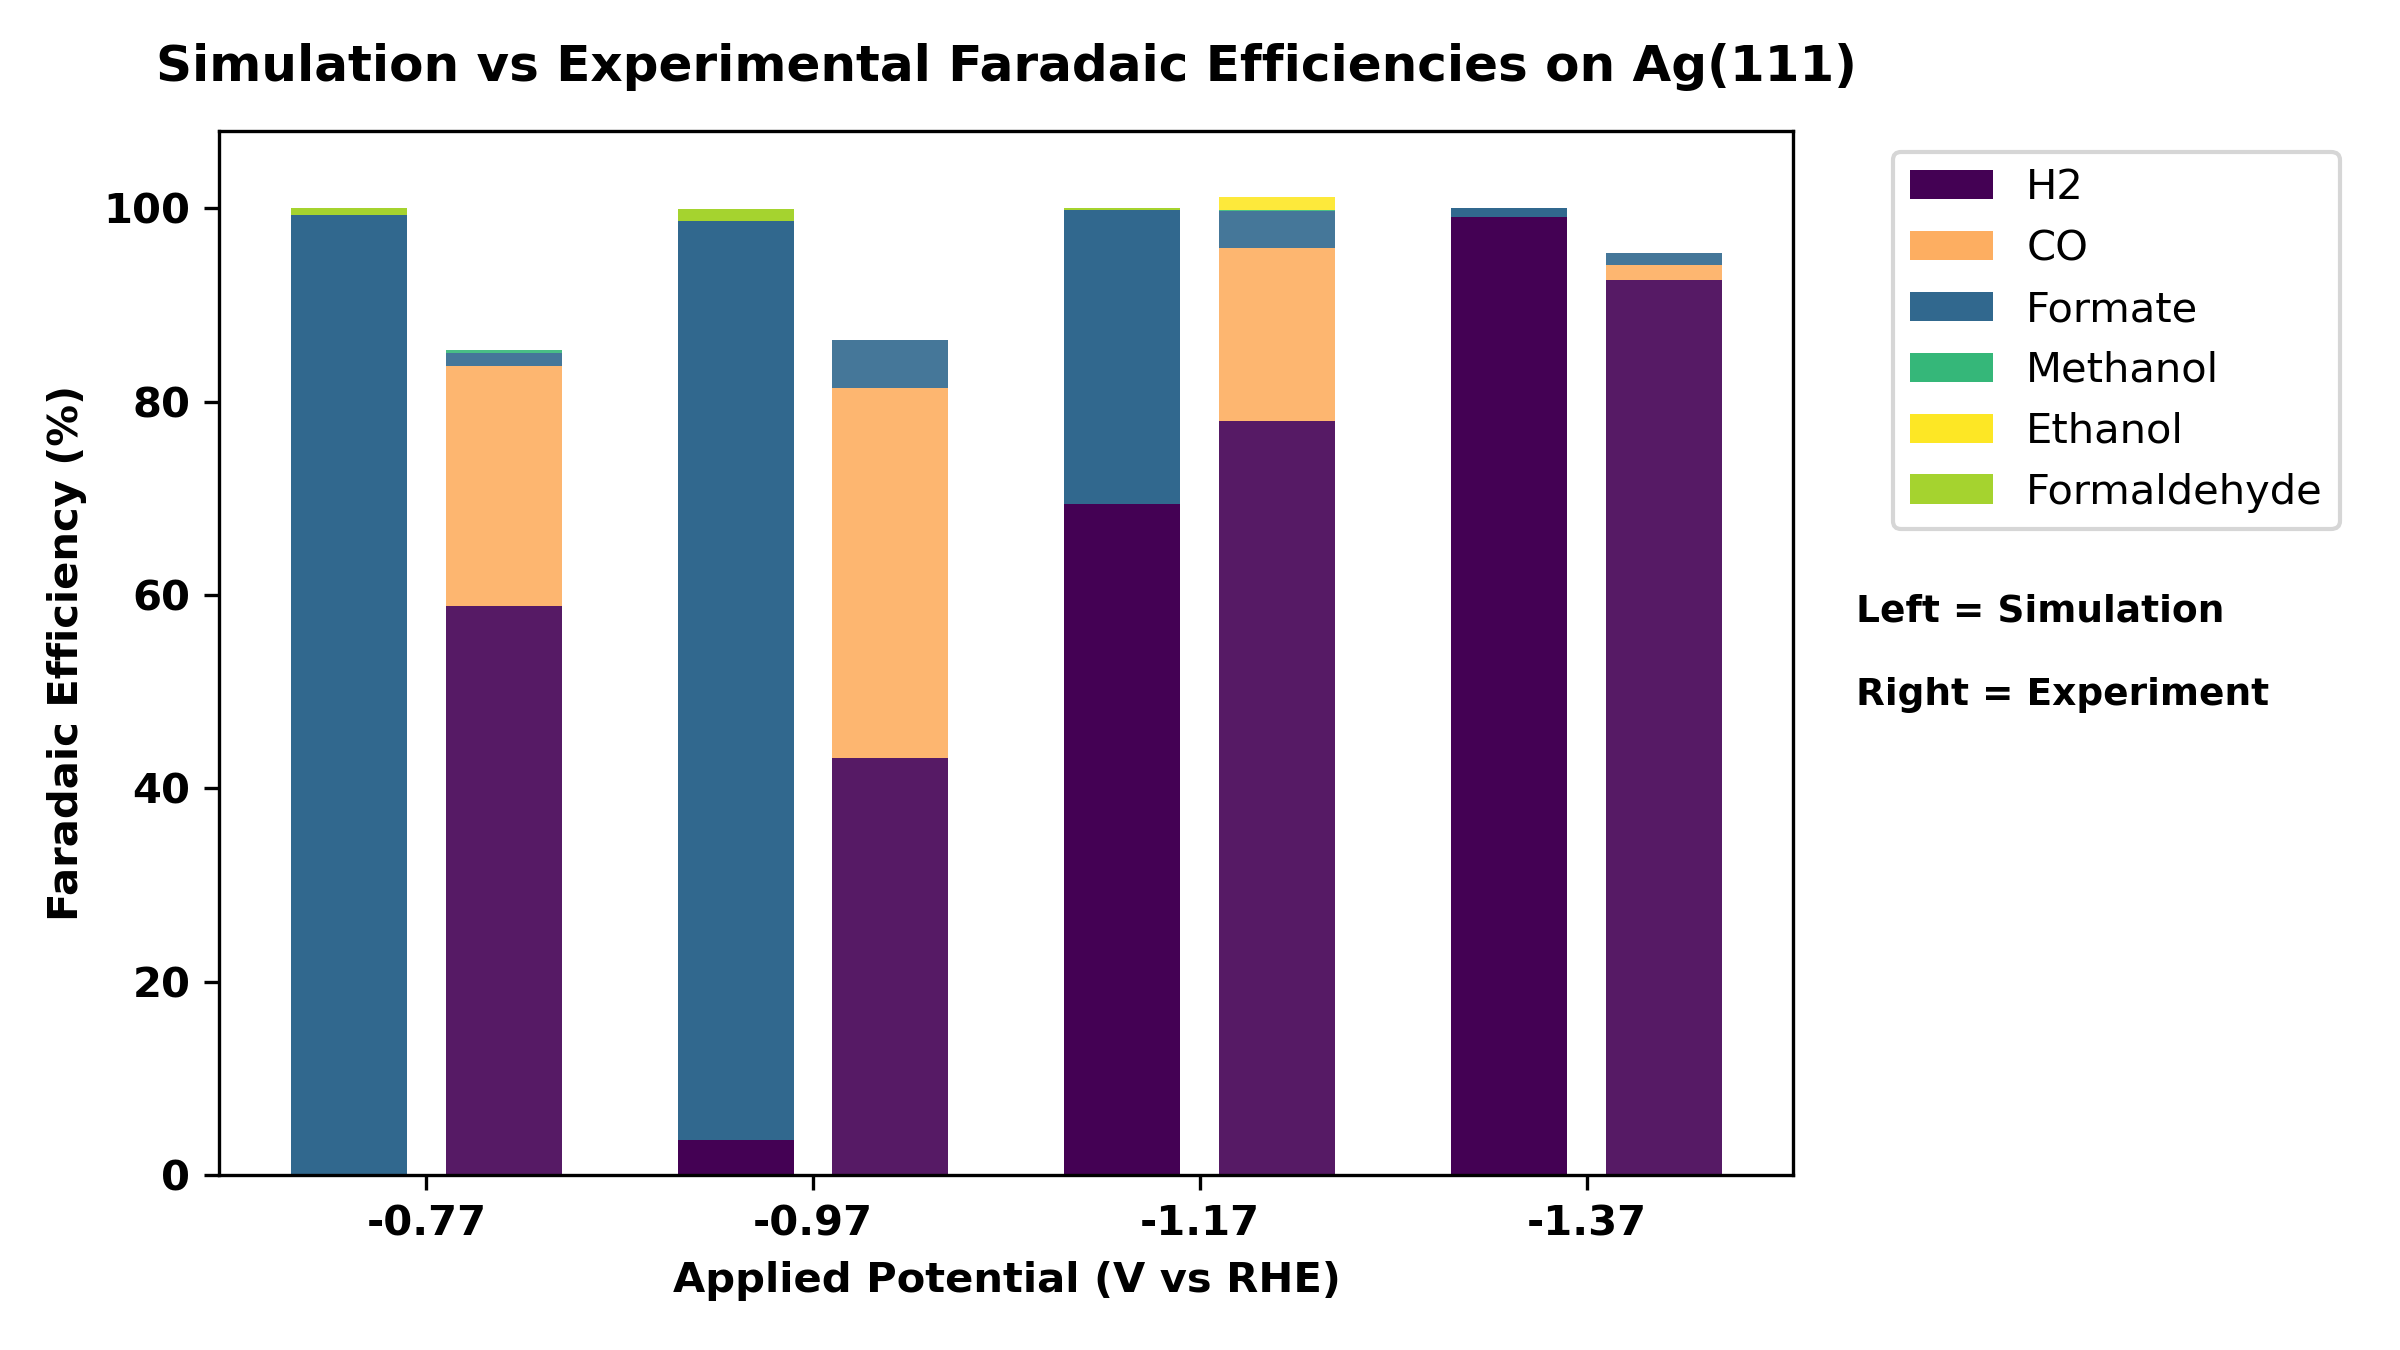

In [12]:
plt.savefig("plt_full.png", dpi=300)
display("image/png", read("plt_full.png"))

In [13]:
selected_species = ["O=CO", "CO-2", "CCO"]
selected_labels  = ["Formate", "Methanol", "Ethanol"]
selected_colors = ["#31688E", "#35B779", "#FDE725",];

In [14]:
sel_idx = [findfirst(==(s), exp.Species) for s in selected_species]
exp_sel = exp[sel_idx, :]
exp_data_sel = Matrix(exp_sel[:, potentials]).*100;

In [15]:
plt.figure(figsize=(6,4))
x = collect(1:length(potentials))
bar_width = 0.3
bottom_sim = zeros(length(potentials))
for (i, sp) in enumerate(selected_species)
    plt.bar(x .- (bar_width/2), exp_data_sel[i, :],
            bar_width, bottom=bottom_sim,
            color=selected_colors[i],
            label=selected_labels[i])
    bottom_sim .+= exp_data_sel[i, :]
end

plt.xticks(x, potentials)
plt.xlabel("Applied Potential (V vs RHE)", fontweight="bold")
plt.ylabel("Faradaic Efficiency (%)", fontweight="bold")
plt.xticks(fontweight="bold")
plt.yticks(fontweight="bold")
plt.ylim(0.0, 10)
plt.title("Experimental Faradaic Efficiencies on Ag(111)", pad = 12, fontweight="bold")
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()

Python: None

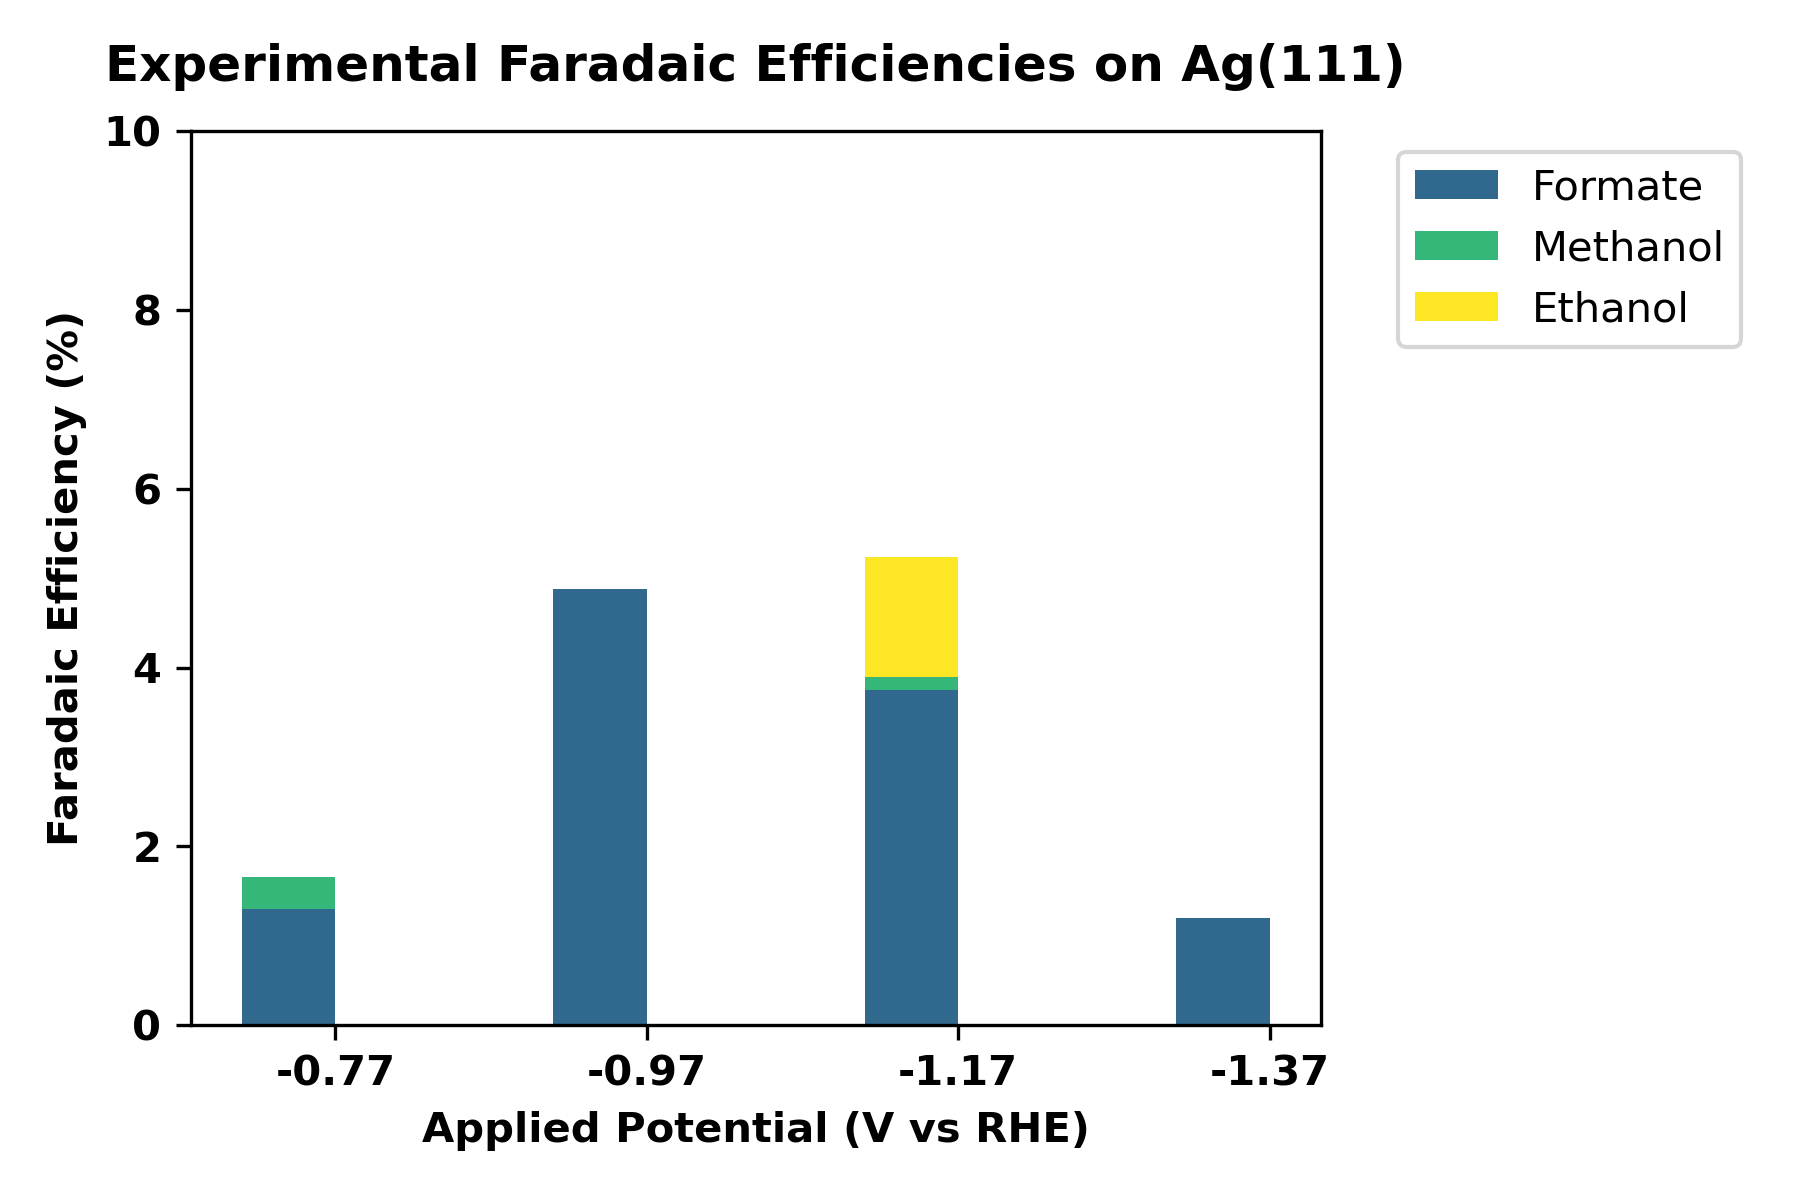

In [16]:
plt.savefig("plt_partial.png", dpi=300)
display("image/png", read("plt_partial.png"))